# 02 — Walk-Forward Modeling

Expanding walk-forward evaluation with an **H-day embargo** (purges training rows
whose forward target overlaps the test block), and **per-fold** bucket edges fit on
training data only.

Both model families are reduced to a common **expected-return signal** so
classification and regression compete on the same footing:
- regressor -> predicted forward return is the signal;
- classifier -> `signal = sum_k P(k) * rbar_k` (per-fold bucket-mean returns).

Metrics: native ML metrics per type (balanced accuracy / log-loss; MAE / $R^2$) plus
the decision-relevant **Rank IC**, **non-overlapping Rank IC**, **ICIR**, and
**hit rate** on the signal. The stitched out-of-sample signals are cached for the
backtest (stage 03).

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.experiment import run_experiment

cfg = load_config(PROJECT_ROOT / "config.yaml")

def _require(path, name):
    if not Path(path).exists():
        raise FileNotFoundError(f"{name} not found at {path}.\nRun 01_features_target.ipynb first.")
    return path

X = pd.read_parquet(_require(cfg.features_path, "features"))
targets = pd.read_parquet(_require(cfg.targets_path, "targets"))
warmup = max(cfg.return_windows)   # skip rows before long-window features exist
print(f"features: {X.shape} | targets: {list(targets.columns)} | warmup: {warmup}")

features: (6661, 266) | targets: ['fwd_ret_5', 'fwd_ret_21', 'fwd_ret_63'] | warmup: 120


## 1 — Run (or load) the walk-forward

Results are cached to `oos_signals.parquet` + `walkforward_metrics.csv`. **Changing
`model:`, `target:`, or `features:` settings requires `force_refresh: true`** to rerun.

In [3]:
if (not cfg.force_refresh) and cfg.signals_path.exists() and cfg.metrics_path.exists():
    metrics = pd.read_csv(cfg.metrics_path)
    signals = pd.read_parquet(cfg.signals_path)
    print("loaded cached walk-forward results")
else:
    metrics, signals = run_experiment(
        X, targets,
        horizons=cfg.horizons,
        model_names=cfg.model_names,
        n_folds=cfg.n_folds,
        min_train_frac=cfg.min_train_frac,
        n_buckets=cfg.n_buckets,
        bucket_method=cfg.bucket_method,
        fixed_bins=cfg.fixed_bins,
        warmup=warmup,
    )
    cfg.signals_path.parent.mkdir(parents=True, exist_ok=True)
    metrics.to_csv(cfg.metrics_path, index=False)
    signals.to_parquet(cfg.signals_path)
    print(f"saved -> {cfg.metrics_path.name}, {cfg.signals_path.name}")

[week H=5] 6536 rows, 6 folds
[month H=21] 6520 rows, 6 folds
[quarter H=63] 6478 rows, 6 folds
saved -> walkforward_metrics.csv, oos_signals.parquet


## 2 — Metrics

In [4]:
cols = ['horizon', 'model', 'kind', 'rank_ic', 'rank_ic_nonoverlap', 'icir',
        'hit_rate', 'balanced_accuracy', 'accuracy', 'log_loss', 'mae', 'rmse', 'r2']
cols = [c for c in cols if c in metrics.columns]
view = metrics[cols].copy()
num = view.select_dtypes('number').columns
view[num] = view[num].round(4)
view.sort_values(['horizon', 'rank_ic_nonoverlap'], ascending=[True, False])

,horizon,model,kind,rank_ic,rank_ic_nonoverlap,icir,hit_rate,balanced_accuracy,accuracy,log_loss,mae,rmse,r2
4,month,logistic_clf,clf,0.1949,0.1571,1.1924,0.4550,0.2333,0.2063,5.1582,NaN,NaN,NaN
5,month,histgbm_clf,clf,0.0823,0.1360,1.2138,0.4913,0.2320,0.2260,1.9454,NaN,NaN,NaN
6,month,ridge_reg,reg,0.1515,0.1299,0.9873,0.4271,NaN,NaN,NaN,0.0907,0.1110,-5.8598
7,month,histgbm_reg,reg,0.0163,0.0364,0.2278,0.4277,NaN,NaN,NaN,0.0471,0.0626,-1.1807
8,quarter,logistic_clf,clf,0.2237,0.3087,0.9022,0.5048,0.2049,0.1842,6.7347,NaN,NaN,NaN
10,quarter,ridge_reg,reg,0.1140,0.0915,0.2313,0.5122,NaN,NaN,NaN,0.1213,0.1561,-4.8161
11,quarter,histgbm_reg,reg,0.0839,0.0811,0.5676,0.4121,NaN,NaN,NaN,0.0725,0.0876,-0.8309
9,quarter,histgbm_clf,clf,-0.0113,0.0013,0.3956,0.4950,0.1776,0.1873,2.3937,NaN,NaN,NaN
0,week,logistic_clf,clf,0.0829,0.0875,1.3694,0.4948,0.2469,0.2287,2.9468,NaN,NaN,NaN
1,week,histgbm_clf,clf,0.0373,0.0797,1.1659,0.4983,0.2514,0.2489,1.7580,NaN,NaN,NaN


## 3 — Rank IC by model and horizon

Non-overlapping Rank IC is the fairer read (it removes the overlap inflation). For a
daily-frequency single-index timing signal, small positive and *consistent* (high
ICIR) values are what matter, not large one-off correlations.

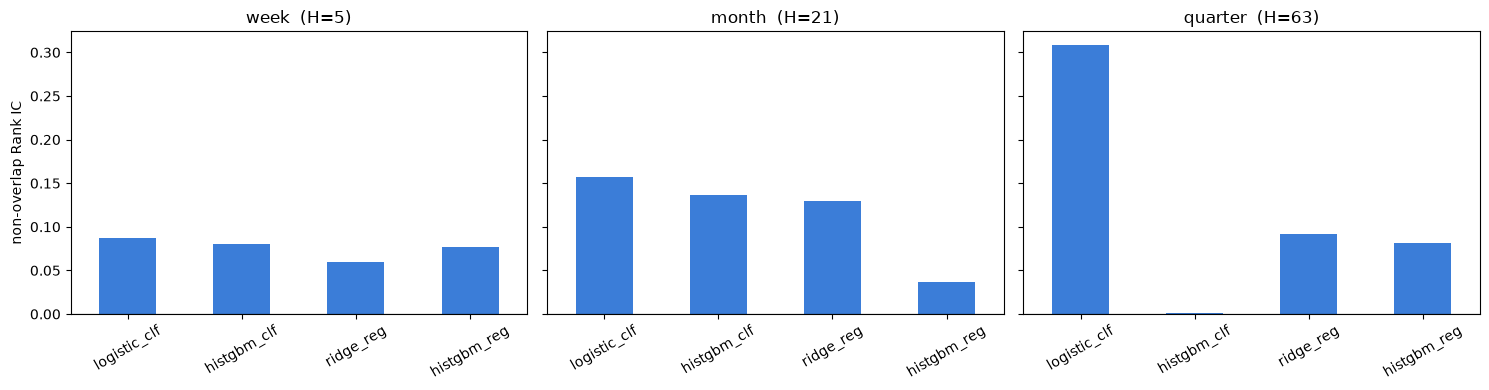

In [5]:
hz = list(cfg.horizons.keys())
fig, axes = plt.subplots(1, len(hz), figsize=(5 * len(hz), 4), sharey=True)
if len(hz) == 1:
    axes = [axes]
for ax, h in zip(axes, hz):
    sub = metrics[metrics.horizon == h].set_index('model')['rank_ic_nonoverlap']
    colors = ['#3b7dd8' if v >= 0 else '#d1495b' for v in sub]
    sub.plot.bar(ax=ax, color=colors)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{h}  (H={cfg.horizons[h]})')
    ax.set_xlabel('')
    ax.set_ylabel('non-overlap Rank IC')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4 — Best model per horizon

Ranked by non-overlapping Rank IC. These signals are already saved; stage 03 will
turn a chosen one into positions, apply costs and roll, and produce the equity /
drawdown / regime visuals.

In [6]:
best = (metrics.sort_values('rank_ic_nonoverlap', ascending=False)
               .groupby('horizon', as_index=False).first())
keep = [c for c in ['horizon', 'model', 'kind', 'rank_ic_nonoverlap', 'icir', 'hit_rate']
        if c in best.columns]
print(best[keep].to_string(index=False))
print(f"\nsignal columns saved for stage 03: "
      f"{[c for c in signals.columns if not c.startswith('realized__')]}")

horizon        model kind  rank_ic_nonoverlap     icir  hit_rate
  month logistic_clf  clf            0.157126 1.192424  0.455010
quarter logistic_clf  clf            0.308705 0.902189  0.504759
   week logistic_clf  clf            0.087471 1.369410  0.494772

signal columns saved for stage 03: ['logistic_clf__h5', 'histgbm_clf__h5', 'ridge_reg__h5', 'histgbm_reg__h5', 'logistic_clf__h21', 'histgbm_clf__h21', 'ridge_reg__h21', 'histgbm_reg__h21', 'logistic_clf__h63', 'histgbm_clf__h63', 'ridge_reg__h63', 'histgbm_reg__h63']
